<a href="https://colab.research.google.com/github/dhanush78945-afk/Assignment1-AIML/blob/main/car_price.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
path = kagglehub.dataset_download("uciml/autompg-dataset")

100%|██████████| 6.31k/6.31k [00:00<00:00, 9.49MB/s]

Extracting files...


In [ ]:
import os
import pandas as pd

# List contents of the downloaded directory to find the data file
file_list = os.listdir(path)
print(f"Files in the downloaded dataset directory: {file_list}")

# Assuming the main data file is a .csv, let's find and load it
csv_files = [f for f in file_list if f.endswith('.csv')]
if csv_files:
    data_file = os.path.join(path, csv_files[0])
    df = pd.read_csv(data_file)
    print(f"Loaded dataset from: {data_file}")
    display(df.head())
    display(df.info())
else:
    print("No CSV file found in the dataset directory. Please check the dataset content.")

Files in the downloaded dataset directory: ['auto-mpg.csv']
Loaded dataset from: /root/.cache/kagglehub/datasets/uciml/autompg-dataset/versions/3/auto-mpg.csv


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


None

In [ ]:
# Inspect unique values in 'horsepower' to understand its non-numeric entries
print("Unique values in 'horsepower' before cleaning:")
print(df['horsepower'].unique())

# Replace '?' with NaN and convert 'horsepower' to numeric
df['horsepower'] = df['horsepower'].replace('?', pd.NA)
df['horsepower'] = pd.to_numeric(df['horsepower'])

# Handle missing values (e.g., impute with the mean)
df['horsepower'].fillna(df['horsepower'].mean(), inplace=True)

# Drop 'car name' column as it's not useful for direct modeling
df = df.drop('car name', axis=1)

# Verify changes
print("\nDataFrame info after cleaning 'horsepower' and dropping 'car name':")
display(df.info())

# Display head to confirm changes
print("\nDataFrame head after cleaning:")
display(df.head())

Unique values in 'horsepower' before cleaning:
['130' '165' '150' '140' '198' '220' '215' '225' '190' '170' '160' '95'
 '97' '85' '88' '46' '87' '90' '113' '200' '210' '193' '?' '100' '105'
 '175' '153' '180' '110' '72' '86' '70' '76' '65' '69' '60' '80' '54'
 '208' '155' '112' '92' '145' '137' '158' '167' '94' '107' '230' '49' '75'
 '91' '122' '67' '83' '78' '52' '61' '93' '148' '129' '96' '71' '98' '115'
 '53' '81' '79' '120' '152' '102' '108' '68' '58' '149' '89' '63' '48'
 '66' '139' '103' '125' '133' '138' '135' '142' '77' '62' '132' '84' '64'
 '74' '116' '82']

DataFrame info after cleaning 'horsepower' and dropping 'car name':
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    floa

/tmp/ipykernel_13175/2585178901.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['horsepower'].fillna(df['horsepower'].mean(), inplace=True)


None


DataFrame head after cleaning:


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
0,18.0,8,307.0,130.0,3504,12.0,70,1
1,15.0,8,350.0,165.0,3693,11.5,70,1
2,18.0,8,318.0,150.0,3436,11.0,70,1
3,16.0,8,304.0,150.0,3433,12.0,70,1
4,17.0,8,302.0,140.0,3449,10.5,70,1


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Define features (X) and target (y)
X = df.drop('mpg', axis=1)  # All columns except 'mpg' are features
y = df['mpg']  # 'mpg' is the target variable

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data split into training and testing sets.")
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

# Initialize and train models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree Regressor': DecisionTreeRegressor(random_state=42),
    'Random Forest Regressor': RandomForestRegressor(random_state=42)
}

performance_metrics = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    performance_metrics[name] = {
        'Mean Squared Error (MSE)': mse,
        'Root Mean Squared Error (RMSE)': rmse,
        'R-squared (R2)': r2
    }

    print(f"\n{name} Performance:")
    print(f"  Mean Squared Error (MSE): {mse:.2f}")
    print(f"  Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"  R-squared (R2): {r2:.2f}")

print("\nAll model training and evaluation complete.")


Data split into training and testing sets.
X_train shape: (318, 7), y_train shape: (318,)
X_test shape: (80, 7), y_test shape: (80,)

Training Linear Regression...

Linear Regression Performance:
  Mean Squared Error (MSE): 8.20
  Root Mean Squared Error (RMSE): 2.86
  R-squared (R2): 0.85

Training Decision Tree Regressor...

Decision Tree Regressor Performance:
  Mean Squared Error (MSE): 11.18
  Root Mean Squared Error (RMSE): 3.34
  R-squared (R2): 0.79

Training Random Forest Regressor...

Random Forest Regressor Performance:
  Mean Squared Error (MSE): 4.60
  Root Mean Squared Error (RMSE): 2.14
  R-squared (R2): 0.91

All model training and evaluation complete.


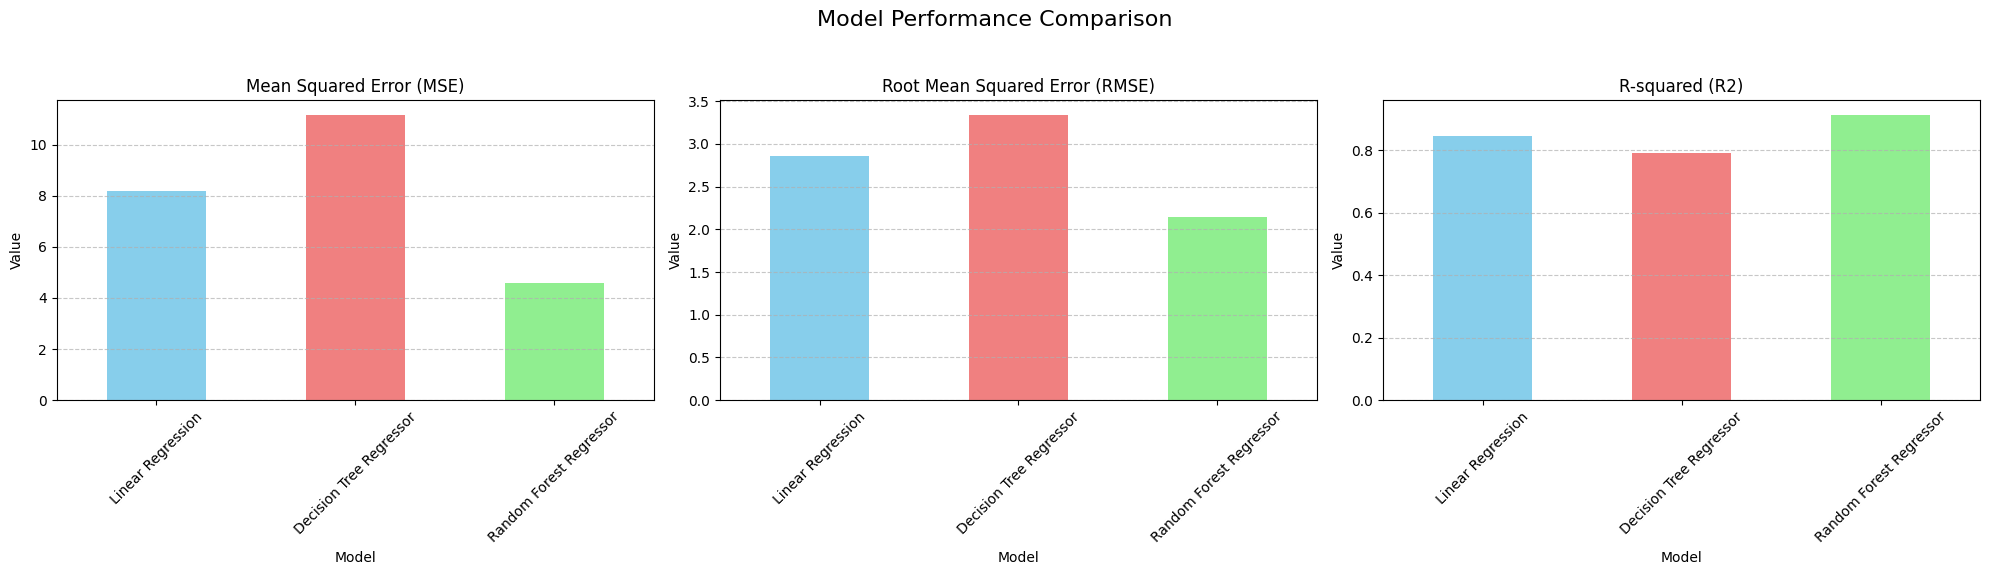

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Convert the performance_metrics dictionary to a DataFrame for easier plotting
metrics_df = pd.DataFrame(performance_metrics).T
metrics_df.index.name = 'Model'

# Prepare data for plotting
metrics_to_plot = ['Mean Squared Error (MSE)', 'Root Mean Squared Error (RMSE)', 'R-squared (R2)']

# Create subplots for each metric
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Model Performance Comparison', fontsize=16)

for i, metric in enumerate(metrics_to_plot):
    ax = axes[i]
    metrics_df[metric].plot(kind='bar', ax=ax, color=['skyblue', 'lightcoral', 'lightgreen'])
    ax.set_title(metric)
    ax.set_ylabel('Value')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.show()
